# Deterministic Actor-Critic: DPG, DDPG, and TD3

>- **NAME: *Radin Cheraghi*

In this notebook, the goal is to build deterministic actor-critic methods from the ground up and connect each implementation detail to the theory from the project. We will move from the deterministic policy-gradient identity to practical deep continuous-control algorithms, and then study why DDPG can fail and how TD3 fixes several of its failure modes.

We will implement and compare the following methods:

$$
\text{DPG}
\quad\longrightarrow\quad
\text{DDPG}
\quad\longrightarrow\quad
\text{TD3}.
$$


This cell standardizes the PyTorch installation used by the notebook. It is needed if you want to use P100 on Kaggle!

First, it removes any preinstalled versions of torch, torchvision, and torchaudio. Kaggle environments often come with these packages already installed, but their versions may differ from the versions expected by this project. The uninstall command is allowed to fail without stopping the notebook, because some of the packages may not be installed yet.

Second, it installs fixed versions of the PyTorch stack:

- torch==2.7.1
- torchvision==0.22.1
- torchaudio==2.7.1

Using exact versions makes the notebook more reproducible across students and avoids version mismatches between PyTorch, torchvision, and torchaudio.


In [ ]:
!python -m pip uninstall -y torch torchvision torchaudio || true

!python -m pip install --no-cache-dir --force-reinstall torch==2.7.1 torchvision==0.22.1 torchaudio==2.7.1 --index-url https://download.pytorch.org/whl/cu126

Found existing installation: torch 2.11.0+cu128
Uninstalling torch-2.11.0+cu128:
  Successfully uninstalled torch-2.11.0+cu128
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 265.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 378.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 279.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 263.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 222.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 246.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

This cell installs Gymnasium with MuJoCo support.


In [ ]:
!pip install "gymnasium[mujoco]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 22.8 MB/s eta 0:00:00


## Import Necessary Libraries


In [ ]:
from pathlib import Path
from IPython.display import display
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from HW3_moving_target_reacher_env import make_moving_reacher, rollout_to_video, embed_video

Note: Using a GPU is not strictly necessary for this project. The neural networks used here are small, and the majority of training time is spent running episodes in the environment (which occurs on the CPU), rather than performing backpropagation updates.


## Explore the Environment

The environment used in this project is a modified version of the Gymnasium MuJoCo `Reacher-v5` task. In the original Reacher environment, a two-link robotic arm must move its fingertip toward a target location. Here, the task is extended into a moving-target tracking problem, where the target position changes over time according to a predefined trajectory.

The environment is implemented as a wrapper around the base Reacher environment. At every timestep, the wrapper updates the target position using a target trajectory function and then recomputes the reward based on the current distance between the fingertip and the moving target. This changes the task from simply reaching a fixed point into continuously tracking a dynamic target.

Three target motion types are supported. A static target keeps the target fixed at a specified position. A circular target moves the target along a circular path using a radius, angular velocity, and center point. A Lissajous target produces a more complex periodic trajectory using separate amplitudes and angular velocities for the x and y directions. These different motion types allow the agent to be evaluated under both simple and more challenging tracking conditions.

The observation can include the original Reacher observation, the current target position, the current target velocity, time, and a phase representation based on sine and cosine features. Including the target position and velocity gives the agent direct information about where the target is and how it is moving, while the phase features provide a compact representation of periodic motion.

The action space is kept the same as the original Reacher environment. The agent outputs continuous torque commands for the arm joints, and these actions are applied to the MuJoCo simulation. The goal of the policy is to choose actions that keep the fingertip close to the moving target throughout the episode.

The reward consists of two components: a distance penalty and a control penalty. The distance penalty encourages the fingertip to stay close to the target, while the control penalty discourages unnecessarily large actions. Therefore, the agent must learn a balance between accurate tracking and smooth, efficient control.

At the start of each episode, the environment time and step counter are reset to zero, and the target is placed at its initial position. During each environment step, the target is synchronized with the current simulation time, the action is applied, the time is advanced, and the target is moved to its next position. Episodes terminate or truncate according to the underlying environment and the configured maximum episode length.


### Task Description

In this task, you will create and inspect a moving-target Reacher environment. The environment uses the MuJoCo `Reacher-v5` task with a circularly moving target. The target follows a circular trajectory with radius `0.15` and angular velocity `1.0`, and each episode is limited to `100` steps.

The observation includes the target position, target velocity, and phase information, allowing the agent to observe both where the target is and how it is moving. To verify that the environment works correctly, you will reset the environment, take random actions from the action space for a short rollout, and print useful diagnostic information such as the reward, fingertip-target distance, and target position at each step.


In [ ]:
# Create the circular moving-target Reacher environment
env = make_moving_reacher(
    motion="circle",
    env_id="Reacher-v5",
    radius=0.15,
    omega=1.0,
    max_episode_steps=100,
    include_target_pos=True,
    include_target_vel=True,
    include_phase=True,
    render_mode=None,
)

# Reset the environment
obs, info = env.reset(seed=0)

# Initialize total reward
total_reward = 0.0

# Run a 10-step random-action rollout
for step in range(10):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    print(
        f"step={step+1:02d} | "
        f"reward={reward:8.3f} | "
        f"distance={info.get('distance', np.nan):.4f} | "
        f"target=({info.get('target_x', np.nan):.3f}, {info.get('target_y', np.nan):.3f})"
    )

    if terminated or truncated:
        break

print(f"Total reward over test rollout: {total_reward:.3f}")

env.close()

step=01 | reward=  -0.064 | distance=0.0602 | target=(0.150, 0.003)
step=02 | reward=  -0.068 | distance=0.0630 | target=(0.150, 0.006)
step=03 | reward=  -0.088 | distance=0.0754 | target=(0.150, 0.009)
step=04 | reward=  -0.105 | distance=0.1024 | target=(0.150, 0.012)
step=05 | reward=  -0.143 | distance=0.1400 | target=(0.149, 0.015)
step=06 | reward=  -0.188 | distance=0.1767 | target=(0.149, 0.018)
step=07 | reward=  -0.212 | distance=0.2096 | target=(0.149, 0.021)
step=08 | reward=  -0.256 | distance=0.2448 | target=(0.148, 0.024)
step=09 | reward=  -0.289 | distance=0.2789 | target=(0.148, 0.027)
step=10 | reward=  -0.315 | distance=0.2998 | target=(0.147, 0.030)
Total reward over test rollout: -1.728


### Task Description

In this task, you will generate a visualization of a rollout in the moving-target Reacher environment. The environment uses a circular target trajectory with radius `0.15`, angular velocity `1.0`, and an episode length of `150` steps. The observation includes the target position, target velocity, and phase features.

Instead of using the MuJoCo renderer, the rollout is recorded using a custom no-render video recorder. The recorder extracts the Reacher state directly from the environment and draws each frame with Matplotlib, including the robotic arm, moving target, fingertip position, target trail, fingertip trail, reward statistics, distance information, and action values.

A random policy is used by setting `policy=None`, so actions are sampled directly from the environment action space. The rollout is saved as a video file, summary statistics are printed, and the resulting video is embedded in the notebook for inspection.


In [ ]:
# Create the videos directory
video_dir = Path("videos")
video_dir.mkdir(parents=True, exist_ok=True)

# Create the circular moving-target Reacher environment
env = make_moving_reacher(
    motion="circle",
    env_id="Reacher-v5",
    radius=0.15,
    omega=1.0,
    max_episode_steps=150,
    include_target_pos=True,
    include_target_vel=True,
    include_phase=True,
    render_mode=None,
)

# Record a random-policy rollout video
video_path, video_stats = rollout_to_video(
    env=env,
    policy=None,
    video_path=video_dir / "random_policy.mp4",
    max_steps=150,
    fps=30,
    seed=0,
    trail_len=20,
)

env.close()

print(video_stats)
display(embed_video(video_path, width=720))

{'return': -31.423422915693365, 'num_steps': 150, 'num_frames': 151, 'mean_reward': -0.20948948610462248, 'mean_distance': 0.20229859528442223, 'final_distance': 0.13543488085269928}


## DPG

### Task Description

Implement a minimal Deterministic Policy Gradient agent for the moving-target Reacher environment. The agent should use:

- an actor network for deterministic continuous actions
- a critic network for estimating \(Q(s, a)\)
- Gaussian exploration noise
- optional target networks
- one-step TD critic updates
- actor updates through the critic

The actor outputs bounded actions using:

$$
a = b + s \tanh(f_\theta(o))
$$

where:

$$
s = \frac{a_{\text{high}} - a_{\text{low}}}{2},
\qquad
b = \frac{a_{\text{high}} + a_{\text{low}}}{2}
$$

The critic target is:

$$
y = r + \gamma (1 - d) Q(o', \mu(o'))
$$

or, when target networks are enabled:

$$
y = r + \gamma (1 - d) Q_{\text{targ}}(o', \mu_{\text{targ}}(o'))
$$

The critic minimizes:

$$
L_Q = \left(Q(o, a) - y\right)^2
$$

The actor maximizes the critic value, implemented as minimizing:

$$
L_\mu = -Q(o, \mu(o))
$$

For target networks, use soft updates:

$$
\theta_{\text{targ}} \leftarrow (1-\tau)\theta_{\text{targ}} + \tau\theta
$$


In [ ]:
# -----------------------------
# Utilities
# -----------------------------

def mlp(sizes, activation=nn.ReLU, output_activation=nn.Identity):
    layers = []
    for i in range(len(sizes) - 1):
        act = activation if i < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[i], sizes[i + 1]), act()]
    return nn.Sequential(*layers)


@torch.no_grad()
def soft_update(net, target_net, tau):
    for p, p_targ in zip(net.parameters(), target_net.parameters()):
        p_targ.data.mul_(1.0 - tau)
        p_targ.data.add_(tau * p.data)


@torch.no_grad()
def hard_update(net, target_net):
    target_net.load_state_dict(net.state_dict())


# -----------------------------
# Actor and critic
# -----------------------------

class DeterministicActor(nn.Module):
    def __init__(self, obs_dim, act_dim, act_low, act_high, hidden=(256, 256)):
        super().__init__()
        self.net = mlp([obs_dim, *hidden, act_dim])

        act_low = torch.as_tensor(act_low, dtype=torch.float32)
        act_high = torch.as_tensor(act_high, dtype=torch.float32)

        self.register_buffer("act_scale", (act_high - act_low) / 2)
        self.register_buffer("act_bias", (act_high + act_low) / 2)

    def forward(self, obs):
        return self.act_bias + self.act_scale * torch.tanh(self.net(obs))


class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(256, 256)):
        super().__init__()
        self.q = mlp([obs_dim + act_dim, *hidden, 1])

    def forward(self, obs, act):
        x = torch.cat([obs, act], dim=-1)
        return self.q(x).squeeze(-1)


# -----------------------------
# Exploration noise
# -----------------------------

class GaussianNoise:
    def __init__(self, act_dim, std=0.1):
        self.act_dim = act_dim
        self.std = std

    def sample(self):
        return np.random.normal(
            loc=0.0,
            scale=self.std,
            size=self.act_dim,
        ).astype(np.float32)

    def reset(self):
        pass


# -----------------------------
# DPG config
# -----------------------------

@dataclass
class DPGConfig:
    gamma: float = 0.99
    actor_lr: float = 1e-4
    critic_lr: float = 1e-3
    tau: float = 0.005
    noise_std: float = 0.1
    hidden: tuple = (256, 256)
    use_target_networks: bool = True


# -----------------------------
# DPG agent
# -----------------------------

class DPGAgent:
    def __init__(self, env, cfg=DPGConfig(), device=None):
        self.cfg = cfg
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))

        self.obs_dim = int(np.prod(env.observation_space.shape))
        self.act_dim = int(np.prod(env.action_space.shape))
        self.act_low = env.action_space.low.astype(np.float32)
        self.act_high = env.action_space.high.astype(np.float32)

        self.actor = DeterministicActor(
            self.obs_dim,
            self.act_dim,
            self.act_low,
            self.act_high,
            cfg.hidden,
        ).to(self.device)

        self.critic = Critic(
            self.obs_dim,
            self.act_dim,
            cfg.hidden,
        ).to(self.device)

        self.actor_targ = DeterministicActor(
            self.obs_dim,
            self.act_dim,
            self.act_low,
            self.act_high,
            cfg.hidden,
        ).to(self.device)

        self.critic_targ = Critic(
            self.obs_dim,
            self.act_dim,
            cfg.hidden,
        ).to(self.device)

        hard_update(self.actor, self.actor_targ)
        hard_update(self.critic, self.critic_targ)

        self.actor_opt = torch.optim.Adam(self.actor.parameters(), lr=cfg.actor_lr)
        self.critic_opt = torch.optim.Adam(self.critic.parameters(), lr=cfg.critic_lr)

        self.noise = GaussianNoise(self.act_dim, cfg.noise_std)
        self.last_transition = None

    @torch.no_grad()
    def select_action(self, obs, explore=True):
        obs_t = torch.as_tensor(
            obs,
            dtype=torch.float32,
            device=self.device,
        ).unsqueeze(0)

        action = self.actor(obs_t)
        action = action.squeeze(0).cpu().numpy()

        if explore:
            action = action + self.noise.sample()

        action = np.clip(action, self.act_low, self.act_high)
        return action.astype(np.float32)

    def store(self, obs, act, rew, next_obs, done):
        self.last_transition = (
            np.asarray(obs, dtype=np.float32).copy(),
            np.asarray(act, dtype=np.float32).copy(),
            float(rew),
            np.asarray(next_obs, dtype=np.float32).copy(),
            float(done),
        )

    def update(self, step=None):
        if self.last_transition is None:
            return {}

        obs, act, rew, next_obs, done = self.last_transition

        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        act_t = torch.as_tensor(act, dtype=torch.float32, device=self.device).unsqueeze(0)
        rew_t = torch.as_tensor([rew], dtype=torch.float32, device=self.device)
        next_obs_t = torch.as_tensor(next_obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        done_t = torch.as_tensor([done], dtype=torch.float32, device=self.device)

        # -------------------------
        # Critic update
        # -------------------------
        with torch.no_grad():
            if self.cfg.use_target_networks:
                next_act = self.actor_targ(next_obs_t)
                next_q = self.critic_targ(next_obs_t, next_act)
            else:
                next_act = self.actor(next_obs_t)
                next_q = self.critic(next_obs_t, next_act)

            target_q = rew_t + self.cfg.gamma * (1.0 - done_t) * next_q

        q = self.critic(obs_t, act_t)
        critic_loss = F.mse_loss(q, target_q)

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            self.critic.parameters(),
            max_norm=10.0,
        )

        self.critic_opt.step()

        # -------------------------
        # Actor update
        # -------------------------
        for p in self.critic.parameters():
            p.requires_grad_(False)

        pi = self.actor(obs_t)
        actor_loss = -self.critic(obs_t, pi).mean()

        self.actor_opt.zero_grad(set_to_none=True)
        actor_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            self.actor.parameters(),
            max_norm=10.0,
        )

        self.actor_opt.step()

        for p in self.critic.parameters():
            p.requires_grad_(True)

        # -------------------------
        # Target network update
        # -------------------------
        if self.cfg.use_target_networks:
            soft_update(self.actor, self.actor_targ, self.cfg.tau)
            soft_update(self.critic, self.critic_targ, self.cfg.tau)

        return {
            "critic_loss": float(critic_loss.item()),
            "actor_loss": float(actor_loss.item()),
            "q": float(q.mean().item()),
            "target_q": float(target_q.mean().item()),
        }

### Task Description

Implement reusable training and evaluation utilities for the DPG agent. These functions will also be used for the next methods, so keep the interface general: the training loop should work with any agent that implements `select_action`, `store`, `update`, and `noise.reset`, while the evaluation loop should run the policy without exploration noise.

During training, the agent interacts with the environment, stores the latest transition, updates its networks, logs episode returns and lengths, and resets the environment at episode boundaries.

For bootstrapping, use only true termination as the terminal signal:

$$
d_{\text{target}} = \mathbb{1}[\text{terminated}]
$$

Do not treat time-limit truncation as terminal for the TD target.

Evaluation should run deterministic actions:

$$
a = \mu(o)
$$

and report the mean return, return standard deviation, and mean fingertip-target distance when available.


In [ ]:
def train_agent(
    env,
    agent,
    steps=50000,
    seed=0,
    log_every=1000,
):
    obs, info = env.reset(seed=seed)

    ep_ret = 0.0
    ep_len = 0
    ep = 0

    history = {
        "returns": [],
        "lengths": [],
        "losses": [],
        "evals": [],
    }

    for t in range(1, steps + 1):
        action = agent.select_action(obs, explore=True)

        next_obs, rew, terminated, truncated, info = env.step(action)

        # Only true termination is terminal for bootstrapping.
        done_for_target = float(terminated)

        agent.store(obs, action, rew, next_obs, done_for_target)
        losses = agent.update(step=t)

        obs = next_obs
        ep_ret += float(rew)
        ep_len += 1

        if losses:
            history["losses"].append({"step": t, **losses})

        if terminated or truncated:
            history["returns"].append(ep_ret)
            history["lengths"].append(ep_len)

            ep += 1
            obs, info = env.reset(seed=seed + ep)

            agent.noise.reset()

            ep_ret = 0.0
            ep_len = 0

        if t % log_every == 0:
            recent = history["returns"][-10:]
            avg_ret = np.mean(recent) if recent else np.nan
            print(f"step={t:6d} | episodes={ep:4d} | recent_return={avg_ret:8.2f}")

    return history

In [ ]:
def evaluate(env, agent, episodes=10, seed=10000):
    returns = []
    distances = []

    for ep in range(episodes):
        agent.noise.reset()

        obs, info = env.reset(seed=seed + ep)

        done = False
        ep_ret = 0.0
        ep_dist = []

        while not done:
            action = agent.select_action(obs, explore=False)

            obs, reward, terminated, truncated, info = env.step(action)

            ep_ret += reward
            done = terminated or truncated

            if "distance" in info:
                ep_dist.append(float(info["distance"]))

        returns.append(float(ep_ret))

        if len(ep_dist) > 0:
            distances.append(float(np.mean(ep_dist)))

    out = {
        "eval_return": float(np.mean(returns)),
        "eval_return_std": float(np.std(returns)),
    }

    if len(distances) > 0:
        out["eval_distance"] = float(np.mean(distances))

    return out

### Train and Evaluate Vanilla DPG


In [ ]:
# -----------------------------
# Reproducibility
# -----------------------------
np.random.seed(0)
torch.manual_seed(0)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)


# -----------------------------
# Create training environment
# -----------------------------
env = make_moving_reacher(
    motion="circle",
    env_id="Reacher-v5",
    radius=0.15,
    omega=1.0,
    max_episode_steps=150,
    include_target_pos=True,
    include_target_vel=True,
    include_phase=True,
    render_mode=None,
)


# -----------------------------
# DPG configuration
# -----------------------------
cfg = DPGConfig(
    gamma=0.99,
    actor_lr=1e-4,
    critic_lr=1e-3,
    tau=0.005,
    noise_std=0.1,
    hidden=(256, 256),
    use_target_networks=False,
)


# -----------------------------
# Create agent
# -----------------------------
agent = DPGAgent(
    env=env,
    cfg=cfg,
)

# -----------------------------
# Train
# -----------------------------
dpg_history = train_agent(
    env=env,
    agent=agent,
    steps=25_000,
    seed=0,
    log_every=1_000,
)

step=  1000 | episodes=   6 | recent_return=  -27.18
step=  2000 | episodes=  13 | recent_return=  -30.77
step=  3000 | episodes=  20 | recent_return=  -28.29
step=  4000 | episodes=  26 | recent_return=  -20.91
step=  5000 | episodes=  33 | recent_return=  -10.51
step=  6000 | episodes=  40 | recent_return=  -24.11
step=  7000 | episodes=  46 | recent_return=  -32.36
step=  8000 | episodes=  53 | recent_return=  -27.60
step=  9000 | episodes=  60 | recent_return=  -25.62
step= 10000 | episodes=  66 | recent_return=  -18.32
step= 11000 | episodes=  73 | recent_return=  -12.43
step= 12000 | episodes=  80 | recent_return=   -9.33
step= 13000 | episodes=  86 | recent_return=  -10.53
step= 14000 | episodes=  93 | recent_return=  -12.16
step= 15000 | episodes= 100 | recent_return=  -13.16
step= 16000 | episodes= 106 | recent_return=  -10.76
step= 17000 | episodes= 113 | recent_return=  -11.82
step= 18000 | episodes= 120 | recent_return=  -14.01
step= 19000 | episodes= 126 | recent_return=  

In [ ]:
# -----------------------------
# Evaluate trained DPG agent
# -----------------------------
eval_stats = evaluate(
    env=env,
    agent=agent,
    episodes=10,
    seed=10_000,
)

print(eval_stats)


# -----------------------------
# Create video directory
# -----------------------------
video_dir = Path("videos")
video_dir.mkdir(parents=True, exist_ok=True)


# -----------------------------
# Deterministic learned policy
# -----------------------------
def learned_policy(obs):
    return agent.select_action(obs, explore=False)


# -----------------------------
# Record rollout video
# -----------------------------
video_path, video_stats = rollout_to_video(
    env=env,
    policy=learned_policy,
    video_path=video_dir / "dpg_learned_policy.mp4",
    max_steps=150,
    fps=30,
    seed=20_000,
    trail_len=20,
)

print(video_stats)
display(embed_video(video_path, width=720))

{'eval_return': -20.34936562770605, 'eval_return_std': 0.05596618116144357, 'eval_distance': 0.1294679423496127}
{'return': -20.28930685520172, 'num_steps': 150, 'num_frames': 151, 'mean_reward': -0.1352620457013448, 'mean_distance': 0.1290204004198313, 'final_distance': 0.156327024102211}


## DDPG


### Task Description

Extend the previous DPG agent into DDPG by adding:

- replay-buffer training
- target actor and target critic networks
- Ornstein-Uhlenbeck exploration noise
- minibatch updates instead of single-transition updates

The same `train_agent` and `evaluate` functions from the previous section should be used here as well.

OU exploration noise:

$$
x_{t+1}
=
x_t
+
\theta(\mu - x_t)\Delta t
+
\sigma \sqrt{\Delta t}\epsilon_t,
\qquad
\epsilon_t \sim \mathcal{N}(0, I)
$$

DDPG critic target:

$$
y
=
r
+
\gamma(1-d)
Q_{\text{targ}}(o', \mu_{\text{targ}}(o'))
$$

Critic loss:

$$
L_Q
=
\frac{1}{B}
\sum_i
\left(Q(o_i, a_i) - y_i\right)^2
$$

Actor loss:

$$
L_\mu
=
-\frac{1}{B}
\sum_i
Q(o_i, \mu(o_i))
$$

Target-network update:

$$
\theta_{\text{targ}}
\leftarrow
(1-\tau)\theta_{\text{targ}} + \tau\theta
$$


In [ ]:
# -----------------------------
# Replay Buffer
# -----------------------------
class ReplayBuffer:
    def __init__(self, obs_dim, act_dim, size):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.next_obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros((size, act_dim), dtype=np.float32)
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.float32)

        self.ptr = 0
        self.size = 0
        self.max_size = size

    def store(self, obs, act, rew, next_obs, done):
        self.obs_buf[self.ptr] = obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.next_obs_buf[self.ptr] = next_obs
        self.done_buf[self.ptr] = done

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample_batch(self, batch_size, device="cpu"):
        idxs = np.random.randint(0, self.size, size=batch_size)

        batch = {
            "obs": self.obs_buf[idxs],
            "act": self.act_buf[idxs],
            "rew": self.rew_buf[idxs],
            "next_obs": self.next_obs_buf[idxs],
            "done": self.done_buf[idxs],
        }

        return {
            k: torch.as_tensor(v, dtype=torch.float32, device=device)
            for k, v in batch.items()
        }


# -----------------------------
# Ornstein-Uhlenbeck noise
# -----------------------------
class OUNoise:
    def __init__(self, act_dim, std=0.1, theta=0.15, dt=0.02, mu=0.0):
        self.act_dim = act_dim
        self.std = std
        self.theta = theta
        self.dt = dt
        self.mu = mu

        self.state = np.ones(self.act_dim, dtype=np.float32) * self.mu

    def reset(self):
        self.state = np.ones(self.act_dim, dtype=np.float32) * self.mu

    def sample(self):
        eps = np.random.randn(self.act_dim).astype(np.float32)

        dx = (
            self.theta * (self.mu - self.state) * self.dt
            + self.std * np.sqrt(self.dt) * eps
        )

        self.state = self.state + dx
        return self.state.astype(np.float32)


# -----------------------------
# DDPG config
# -----------------------------

@dataclass
class DDPGConfig(DPGConfig):
    replay_size: int = 100_000
    batch_size: int = 128
    update_after: int = 1_000
    update_every: int = 1

    use_target_networks: bool = True
    use_ou_noise: bool = True


# -----------------------------
# DDPG agent
# -----------------------------

class DDPGAgent(DPGAgent):
    def __init__(self, env, cfg=DDPGConfig(), device=None):
        super().__init__(env, cfg, device)

        self.replay = ReplayBuffer(
            obs_dim=self.obs_dim,
            act_dim=self.act_dim,
            size=cfg.replay_size,
        )

        if cfg.use_ou_noise:
            self.noise = OUNoise(
                act_dim=self.act_dim,
                std=cfg.noise_std,
                dt=getattr(env, "dt", 0.02),
            )

        self.total_stored = 0

    def store(self, obs, act, rew, next_obs, done):
        self.replay.store(obs, act, rew, next_obs, done)
        self.total_stored += 1

    def update(self, step=None):
        if self.replay.size < self.cfg.update_after:
            return {}

        if step is not None and step % self.cfg.update_every != 0:
            return {}

        batch = self.replay.sample_batch(
            batch_size=self.cfg.batch_size,
            device=self.device,
        )

        obs = batch["obs"]
        act = batch["act"]
        rew = batch["rew"]
        next_obs = batch["next_obs"]
        done = batch["done"]

        # -------------------------
        # Critic target
        # -------------------------
        with torch.no_grad():
            next_act = self.actor_targ(next_obs)
            next_q = self.critic_targ(next_obs, next_act)
            target_q = rew + self.cfg.gamma * (1.0 - done) * next_q

        # -------------------------
        # Critic update
        # -------------------------
        q = self.critic(obs, act)
        critic_loss = F.mse_loss(q, target_q)

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            self.critic.parameters(),
            max_norm=10.0,
        )

        self.critic_opt.step()

        # -------------------------
        # Actor update
        # -------------------------
        for p in self.critic.parameters():
            p.requires_grad = False

        pi = self.actor(obs)
        actor_loss = -self.critic(obs, pi).mean()

        self.actor_opt.zero_grad(set_to_none=True)
        actor_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            self.actor.parameters(),
            max_norm=10.0,
        )

        self.actor_opt.step()

        for p in self.critic.parameters():
            p.requires_grad = True

        # -------------------------
        # Target-network update
        # -------------------------
        soft_update(self.actor, self.actor_targ, self.cfg.tau)
        soft_update(self.critic, self.critic_targ, self.cfg.tau)

        return {
            "critic_loss": float(critic_loss.item()),
            "actor_loss": float(actor_loss.item()),
            "q": float(q.mean().item()),
            "target_q": float(target_q.mean().item()),
            "replay_size": self.replay.size,
        }

### Train and Evaluate DDPG Agent


In [ ]:
# -----------------------------
# DDPG configuration
# -----------------------------
np.random.seed(0)
torch.manual_seed(0)

ddpg_cfg = DDPGConfig(
    gamma=0.99,
    actor_lr=1e-4,
    critic_lr=1e-3,
    tau=0.005,
    noise_std=0.2,
    hidden=(256, 256),
    replay_size=100_000,
    batch_size=128,
    update_after=1_000,
    update_every=1,
)


# -----------------------------
# Create and train DDPG agent
# -----------------------------
ddpg_agent = DDPGAgent(
    env=env,
    cfg=ddpg_cfg,
)

print("Training device:", ddpg_agent.device)

ddpg_history = train_agent(
    env=env,
    agent=ddpg_agent,
    steps=25_000,
    seed=0,
    log_every=1_000,
)

Training device: cuda
step=  1000 | episodes=   6 | recent_return=  -22.38
step=  2000 | episodes=  13 | recent_return=  -23.90
step=  3000 | episodes=  20 | recent_return=  -23.79
step=  4000 | episodes=  26 | recent_return=  -17.61
step=  5000 | episodes=  33 | recent_return=   -8.14
step=  6000 | episodes=  40 | recent_return=   -4.51
step=  7000 | episodes=  46 | recent_return=   -4.22
step=  8000 | episodes=  53 | recent_return=   -3.77
step=  9000 | episodes=  60 | recent_return=   -3.29
step= 10000 | episodes=  66 | recent_return=   -3.32
step= 11000 | episodes=  73 | recent_return=   -3.53
step= 12000 | episodes=  80 | recent_return=   -5.24
step= 13000 | episodes=  86 | recent_return=   -7.45
step= 14000 | episodes=  93 | recent_return=   -4.19
step= 15000 | episodes= 100 | recent_return=   -3.28
step= 16000 | episodes= 106 | recent_return=   -2.90
step= 17000 | episodes= 113 | recent_return=   -2.56
step= 18000 | episodes= 120 | recent_return=   -2.50
step= 19000 | episodes= 

In [ ]:
# Evaluate the trained agent
eval_stats = evaluate(
    env,
    ddpg_agent,
    episodes=10,
    seed=10_000,
)

print(eval_stats)


# Define a deterministic learned policy for video rollout
def ddpg_policy(obs):
    return ddpg_agent.select_action(obs, explore=False)


# Record a rollout video using the learned policy
video_path, video_stats = rollout_to_video(
    env=env,
    policy=ddpg_policy,
    video_path=video_dir / "ddpg_learned_policy.mp4",
    max_steps=150,
    fps=30,
    seed=20_000,
    trail_len=20,
)

print(video_stats)
display(embed_video(video_path, width=720))

{'eval_return': -1.1654583404635261, 'eval_return_std': 0.010614098073947538, 'eval_distance': 0.0074910322346258915}
{'return': -1.1427920589458245, 'num_steps': 150, 'num_frames': 151, 'mean_reward': -0.007618613726305488, 'mean_distance': 0.007352479773495967, 'final_distance': 0.012057785876095295}


## TD3


### Task Description

Implement TD3 by extending the previous DDPG agent. TD3 modifies DDPG using three main changes:

1. **Clipped double Q-learning**: use two critics and bootstrap from the smaller target value.
2. **Target policy smoothing**: add clipped noise to the target action.
3. **Delayed policy updates**: update the actor and target networks less frequently than the critics.

Target action:

$$
a' = \text{clip}\left(\mu_{\text{targ}}(o') + \epsilon,\ a_{\min},\ a_{\max}\right)
$$

where:

$$
\epsilon \sim \text{clip}\left(\mathcal{N}(0, \sigma^2), -c, c\right)
$$

TD3 target:

$$
y = r + \gamma(1-d)\min_{i=1,2} Q_{i,\text{targ}}(o', a')
$$

Critic loss:

$$
L_Q =
\text{MSE}(Q_1(o,a), y)
+
\text{MSE}(Q_2(o,a), y)
$$

Delayed actor loss:

$$
L_\mu = -\frac{1}{B}\sum_i Q_1(o_i, \mu(o_i))
$$

Use the same replay buffer, training loop, and evaluation function from the previous DDPG section.


In [ ]:
# -----------------------------
# TD3 config
# -----------------------------
@dataclass
class TD3Config(DDPGConfig):
    policy_delay: int = 2
    target_noise_std: float = 0.2
    target_noise_clip: float = 0.5

    use_ou_noise: bool = False


# -----------------------------
# TD3 agent
# -----------------------------
class TD3Agent(DDPGAgent):
    def __init__(self, env, cfg=TD3Config(), device=None):
        # Builds actor, actor_targ, critic, critic_targ, replay buffer, and noise
        super().__init__(env, cfg, device)

        # Reuse inherited critic as critic1
        self.critic1 = self.critic
        self.critic1_targ = self.critic_targ

        # Create second critic Q2
        self.critic2 = Critic(
            self.obs_dim,
            self.act_dim,
            cfg.hidden,
        ).to(self.device)

        # Create target critic Q2_targ
        self.critic2_targ = Critic(
            self.obs_dim,
            self.act_dim,
            cfg.hidden,
        ).to(self.device)

        # Hard-update critic2 target network
        hard_update(self.critic2, self.critic2_targ)

        # Optimizer over both critics
        self.critic_opt = torch.optim.Adam(
            list(self.critic1.parameters()) + list(self.critic2.parameters()),
            lr=cfg.critic_lr,
        )

        self.total_updates = 0

    def update(self, step=None):
        if self.replay.size < self.cfg.update_after:
            return {}

        if step is not None and step % self.cfg.update_every != 0:
            return {}

        self.total_updates += 1

        batch = self.replay.sample_batch(
            batch_size=self.cfg.batch_size,
            device=self.device,
        )

        obs = batch["obs"]
        act = batch["act"]
        rew = batch["rew"]
        next_obs = batch["next_obs"]
        done = batch["done"]

        # --------------------------------------------------
        # TD3 critic target
        # --------------------------------------------------
        with torch.no_grad():
            noise = torch.randn_like(act) * self.cfg.target_noise_std
            noise = torch.clamp(
                noise,
                -self.cfg.target_noise_clip,
                self.cfg.target_noise_clip,
            )

            next_act = self.actor_targ(next_obs) + noise

            act_low = torch.as_tensor(
                self.act_low,
                dtype=torch.float32,
                device=self.device,
            )
            act_high = torch.as_tensor(
                self.act_high,
                dtype=torch.float32,
                device=self.device,
            )

            next_act = torch.max(torch.min(next_act, act_high), act_low)

            q1_targ = self.critic1_targ(next_obs, next_act)
            q2_targ = self.critic2_targ(next_obs, next_act)

            q_targ_min = torch.min(q1_targ, q2_targ)

            target_q = rew + self.cfg.gamma * (1.0 - done) * q_targ_min

        # --------------------------------------------------
        # Critic update
        # --------------------------------------------------
        q1 = self.critic1(obs, act)
        q2 = self.critic2(obs, act)

        critic1_loss = F.mse_loss(q1, target_q)
        critic2_loss = F.mse_loss(q2, target_q)
        critic_loss = critic1_loss + critic2_loss

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(self.critic1.parameters()) + list(self.critic2.parameters()),
            max_norm=10.0,
        )

        self.critic_opt.step()

        metrics = {
            "critic_loss": float(critic_loss.item()),
            "critic1_loss": float(critic1_loss.item()),
            "critic2_loss": float(critic2_loss.item()),
            "q1": float(q1.mean().item()),
            "q2": float(q2.mean().item()),
            "target_q": float(target_q.mean().item()),
            "replay_size": self.replay.size,
        }

        # --------------------------------------------------
        # Delayed actor update
        # --------------------------------------------------
        if self.total_updates % self.cfg.policy_delay == 0:
            for p in self.critic1.parameters():
                p.requires_grad = False
            for p in self.critic2.parameters():
                p.requires_grad = False

            pi = self.actor(obs)
            actor_loss = -self.critic1(obs, pi).mean()

            self.actor_opt.zero_grad(set_to_none=True)
            actor_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                self.actor.parameters(),
                max_norm=10.0,
            )

            self.actor_opt.step()

            for p in self.critic1.parameters():
                p.requires_grad = True
            for p in self.critic2.parameters():
                p.requires_grad = True

            soft_update(self.actor, self.actor_targ, self.cfg.tau)
            soft_update(self.critic1, self.critic1_targ, self.cfg.tau)
            soft_update(self.critic2, self.critic2_targ, self.cfg.tau)

            metrics["actor_loss"] = float(actor_loss.item())

        return metrics

### Train and Evaluate TD3 Agent


In [ ]:
np.random.seed(0)
torch.manual_seed(0)

td3_cfg = TD3Config(
    gamma=0.99,
    actor_lr=1e-4,
    critic_lr=1e-3,
    tau=0.005,

    # exploration noise for data collection
    noise_std=0.1,

    # replay
    replay_size=100_000,
    batch_size=128,
    update_after=1_000,
    update_every=1,

    # TD3 additions
    policy_delay=2,
    target_noise_std=0.2,
    target_noise_clip=0.5,

    hidden=(256, 256),
)

td3_agent = TD3Agent(
    env=env,
    cfg=td3_cfg,
)

print("Training device:", td3_agent.device)

td3_history = train_agent(
    env=env,
    agent=td3_agent,
    steps=25_000,
    seed=0,
    log_every=1_000,
)

Training device: cuda
step=  1000 | episodes=   6 | recent_return=  -22.23
step=  2000 | episodes=  13 | recent_return=  -23.55
step=  3000 | episodes=  20 | recent_return=  -23.24
step=  4000 | episodes=  26 | recent_return=  -18.70
step=  5000 | episodes=  33 | recent_return=  -18.55
step=  6000 | episodes=  40 | recent_return=  -15.30
step=  7000 | episodes=  46 | recent_return=  -14.96
step=  8000 | episodes=  53 | recent_return=  -17.66
step=  9000 | episodes=  60 | recent_return=  -16.71
step= 10000 | episodes=  66 | recent_return=  -13.41
step= 11000 | episodes=  73 | recent_return=   -8.97
step= 12000 | episodes=  80 | recent_return=   -6.37
step= 13000 | episodes=  86 | recent_return=   -6.08
step= 14000 | episodes=  93 | recent_return=   -5.45
step= 15000 | episodes= 100 | recent_return=   -4.91
step= 16000 | episodes= 106 | recent_return=   -4.53
step= 17000 | episodes= 113 | recent_return=   -4.03
step= 18000 | episodes= 120 | recent_return=   -3.71
step= 19000 | episodes= 

In [ ]:
# Evaluate the trained agent
eval_stats = evaluate(
    env,
    td3_agent,
    episodes=10,
    seed=10_000,
)

print(eval_stats)


# Define a deterministic learned policy for video rollout
def td3_policy(obs):
    return td3_agent.select_action(obs, explore=False)


# Record a rollout video using the learned policy
video_path, video_stats = rollout_to_video(
    env=env,
    policy=td3_policy,  # important: use td3_policy, not ddpg_policy
    video_path=video_dir / "td3_learned_policy.mp4",
    max_steps=150,
    fps=30,
    seed=20_000,
    trail_len=20,
)

print(video_stats)
display(embed_video(video_path, width=720))

{'eval_return': -2.3709381641582477, 'eval_return_std': 0.013959493861268721, 'eval_distance': 0.01559922848575904}
{'return': -2.3606764715325634, 'num_steps': 150, 'num_frames': 151, 'mean_reward': -0.01573784314355042, 'mean_distance': 0.015518235003498072, 'final_distance': 0.044876907020807266}


### Ablations

In this final section, you will study the effect of each TD3 improvement by training and evaluating several TD3-like agents.

Create three ablated TD3 agents. Each agent should remove exactly one TD3 addition while keeping the rest of the algorithm unchanged:

1. **No clipped double-Q learning**  
   Use only one critic, as in DDPG.

2. **No target policy smoothing**  
   Do not add clipped noise to the target action.

3. **No delayed policy updates**  
   Update the actor at every critic update instead of every `policy_delay` steps.

Train each ablated agent using the same environment, training loop, number of steps, and evaluation protocol as the full TD3 agent. Then compare their learning curves against:

- DPG
- DDPG
- full TD3
- the three TD3 ablations

Use the results to discuss which TD3 component has the largest effect on performance and stability in the moving-target Reacher task.


In [ ]:
def make_ablation_env():
    return make_moving_reacher(
        motion="circle",
        env_id="Reacher-v5",
        radius=0.15,
        omega=1.0,
        max_episode_steps=150,
        include_target_pos=True,
        include_target_vel=True,
        include_phase=True,
        render_mode=None,
    )

In [ ]:
class NoDoubleQTD3Agent(DDPGAgent):
    def __init__(self, env, cfg=TD3Config(), device=None):
        super().__init__(env, cfg, device)
        self.total_updates = 0

    def update(self, step=None):
        if self.replay.size < self.cfg.update_after:
            return {}

        if step is not None and step % self.cfg.update_every != 0:
            return {}

        self.total_updates += 1

        batch = self.replay.sample_batch(
            batch_size=self.cfg.batch_size,
            device=self.device,
        )

        obs = batch["obs"]
        act = batch["act"]
        rew = batch["rew"]
        next_obs = batch["next_obs"]
        done = batch["done"]

        # -------------------------
        # Target with policy smoothing, but only one critic
        # -------------------------
        with torch.no_grad():
            noise = torch.randn_like(act) * self.cfg.target_noise_std
            noise = torch.clamp(
                noise,
                -self.cfg.target_noise_clip,
                self.cfg.target_noise_clip,
            )

            next_act = self.actor_targ(next_obs) + noise

            act_low = torch.as_tensor(
                self.act_low,
                dtype=torch.float32,
                device=self.device,
            )
            act_high = torch.as_tensor(
                self.act_high,
                dtype=torch.float32,
                device=self.device,
            )

            next_act = torch.max(torch.min(next_act, act_high), act_low)

            next_q = self.critic_targ(next_obs, next_act)
            target_q = rew + self.cfg.gamma * (1.0 - done) * next_q

        # -------------------------
        # Critic update
        # -------------------------
        q = self.critic(obs, act)
        critic_loss = F.mse_loss(q, target_q)

        self.critic_opt.zero_grad(set_to_none=True)
        critic_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            self.critic.parameters(),
            max_norm=10.0,
        )

        self.critic_opt.step()

        metrics = {
            "critic_loss": float(critic_loss.item()),
            "q": float(q.mean().item()),
            "target_q": float(target_q.mean().item()),
            "replay_size": self.replay.size,
        }

        # -------------------------
        # Delayed actor update
        # -------------------------
        if self.total_updates % self.cfg.policy_delay == 0:
            for p in self.critic.parameters():
                p.requires_grad_(False)

            pi = self.actor(obs)
            actor_loss = -self.critic(obs, pi).mean()

            self.actor_opt.zero_grad(set_to_none=True)
            actor_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                self.actor.parameters(),
                max_norm=10.0,
            )

            self.actor_opt.step()

            for p in self.critic.parameters():
                p.requires_grad_(True)

            soft_update(self.actor, self.actor_targ, self.cfg.tau)
            soft_update(self.critic, self.critic_targ, self.cfg.tau)

            metrics["actor_loss"] = float(actor_loss.item())

        return metrics

In [ ]:
base_ablation_kwargs = dict(
    gamma=0.99,
    actor_lr=1e-4,
    critic_lr=1e-3,
    tau=0.005,
    noise_std=0.1,
    replay_size=100_000,
    batch_size=128,
    update_after=1_000,
    update_every=1,
    hidden=(256, 256),
)

# Full TD3 reference config
full_td3_cfg = TD3Config(
    **base_ablation_kwargs,
    policy_delay=2,
    target_noise_std=0.2,
    target_noise_clip=0.5,
)

# Ablation 1: no clipped double-Q
no_double_q_cfg = TD3Config(
    **base_ablation_kwargs,
    policy_delay=2,
    target_noise_std=0.2,
    target_noise_clip=0.5,
)

# Ablation 2: no target policy smoothing
no_smoothing_cfg = TD3Config(
    **base_ablation_kwargs,
    policy_delay=2,
    target_noise_std=0.0,
    target_noise_clip=0.0,
)

# Ablation 3: no delayed policy updates
no_delay_cfg = TD3Config(
    **base_ablation_kwargs,
    policy_delay=1,
    target_noise_std=0.2,
    target_noise_clip=0.5,
)

In [ ]:
def train_and_eval_ablation(name, agent_cls, cfg, train_steps=25_000, seed=0):
    print(f"\n========== Training {name} ==========")

    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    env_i = make_ablation_env()

    agent_i = agent_cls(
        env=env_i,
        cfg=cfg,
    )

    print("Training device:", agent_i.device)

    history_i = train_agent(
        env=env_i,
        agent=agent_i,
        steps=train_steps,
        seed=seed,
        log_every=1_000,
    )

    eval_i = evaluate(
        env=env_i,
        agent=agent_i,
        episodes=10,
        seed=10_000,
    )

    print(f"{name} eval:", eval_i)

    env_i.close()

    return agent_i, history_i, eval_i

In [ ]:
# Full TD3, if you want to retrain it in the same comparison setup
full_td3_agent, full_td3_history, full_td3_eval = train_and_eval_ablation(
    name="Full TD3",
    agent_cls=TD3Agent,
    cfg=full_td3_cfg,
    train_steps=25_000,
    seed=0,
)

# Ablation 1: no clipped double-Q
no_double_q_agent, no_double_q_history, no_double_q_eval = train_and_eval_ablation(
    name="No Double Q",
    agent_cls=NoDoubleQTD3Agent,
    cfg=no_double_q_cfg,
    train_steps=25_000,
    seed=0,
)

# Ablation 2: no target policy smoothing
no_smoothing_agent, no_smoothing_history, no_smoothing_eval = train_and_eval_ablation(
    name="No Target Smoothing",
    agent_cls=TD3Agent,
    cfg=no_smoothing_cfg,
    train_steps=25_000,
    seed=0,
)

# Ablation 3: no delayed policy updates
no_delay_agent, no_delay_history, no_delay_eval = train_and_eval_ablation(
    name="No Delayed Updates",
    agent_cls=TD3Agent,
    cfg=no_delay_cfg,
    train_steps=25_000,
    seed=0,
)


========== Training Full TD3 ==========
Training device: cuda
step=  1000 | episodes=   6 | recent_return=  -22.23
step=  2000 | episodes=  13 | recent_return=  -24.08
step=  3000 | episodes=  20 | recent_return=  -21.14
step=  4000 | episodes=  26 | recent_return=  -18.13
step=  5000 | episodes=  33 | recent_return=  -19.26
step=  6000 | episodes=  40 | recent_return=  -17.31
step=  7000 | episodes=  46 | recent_return=  -14.23
step=  8000 | episodes=  53 | recent_return=  -13.04
step=  9000 | episodes=  60 | recent_return=  -10.74
step= 10000 | episodes=  66 | recent_return=   -8.52
step= 11000 | episodes=  73 | recent_return=   -5.97
step= 12000 | episodes=  80 | recent_return=   -4.47
step= 13000 | episodes=  86 | recent_return=   -3.67
step= 14000 | episodes=  93 | recent_return=   -2.95
step= 15000 | episodes= 100 | recent_return=   -3.12
step= 16000 | episodes= 106 | recent_return=   -3.25
step= 17000 | episodes= 113 | recent_return=   -2.79
step= 18000 | episodes= 120 | recent

In [ ]:
import matplotlib.pyplot as plt

def moving_average(x, window=10):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_learning_curves(histories, window=10):
    plt.figure(figsize=(10, 6))

    for name, hist in histories.items():
        returns = np.asarray(hist["returns"], dtype=np.float32)
        lengths = np.asarray(hist["lengths"], dtype=np.float32)

        if len(returns) == 0:
            continue

        steps = np.cumsum(lengths)
        smoothed = moving_average(returns, window=window)

        if len(smoothed) < len(returns):
            steps = steps[-len(smoothed):]

        plt.plot(steps, smoothed, label=name)

    plt.xlabel("Environment steps")
    plt.ylabel(f"Episode return, moving average window={window}")
    plt.title("DPG / DDPG / TD3 Ablation Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

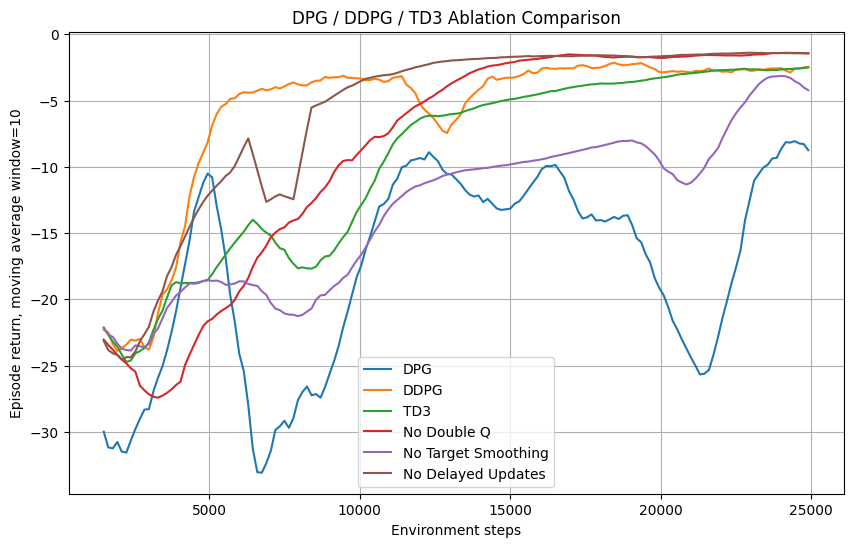

In [ ]:
histories_to_plot = {}

if "dpg_history" in globals():
    histories_to_plot["DPG"] = dpg_history

if "ddpg_history" in globals():
    histories_to_plot["DDPG"] = ddpg_history

if "td3_history" in globals():
    histories_to_plot["TD3"] = td3_history
else:
    histories_to_plot["TD3"] = full_td3_history

histories_to_plot["No Double Q"] = no_double_q_history
histories_to_plot["No Target Smoothing"] = no_smoothing_history
histories_to_plot["No Delayed Updates"] = no_delay_history

plot_learning_curves(histories_to_plot, window=10)

In [ ]:
dpg_eval_stats = evaluate(env, agent, episodes=10, seed=10_000)
ddpg_eval_stats = evaluate(env, ddpg_agent, episodes=10, seed=10_000)
td3_eval_stats = evaluate(env, td3_agent, episodes=10, seed=10_000)

In [ ]:
import pandas as pd

eval_rows = []

if "dpg_eval_stats" in globals():
    eval_rows.append({"method": "DPG", **dpg_eval_stats})

if "ddpg_eval_stats" in globals():
    eval_rows.append({"method": "DDPG", **ddpg_eval_stats})

if "td3_eval_stats" in globals():
    eval_rows.append({"method": "TD3", **td3_eval_stats})
else:
    eval_rows.append({"method": "TD3", **full_td3_eval})

eval_rows += [
    {"method": "No Double Q", **no_double_q_eval},
    {"method": "No Target Smoothing", **no_smoothing_eval},
    {"method": "No Delayed Updates", **no_delay_eval},
]

eval_df = pd.DataFrame(eval_rows)
eval_df

,method,eval_return,eval_return_std,eval_distance
0,DPG,-20.349525,0.055897,0.129468
1,DDPG,-1.165384,0.010612,0.007489
2,TD3,-2.371580,0.013612,0.015602
3,No Double Q,-1.485151,0.042299,0.009581
4,No Target Smoothing,-5.143995,0.014879,0.032883
5,No Delayed Updates,-1.274691,0.011692,0.008357


DPG learned very poorly and gave inaccurate final tracking results because it trained on related transitions one at a time, without using a replay buffer or minibatches. DDPG performed best, showing that replay buffers and target networks were important.

For the TD3 versions, removing target policy smoothing caused the biggest drop in performance and made training less stable. This suggests that policy smoothing was the most important TD3 feature for this task. Removing double-Q learning or delayed policy updates did not have much negative effect.

The full TD3 model was stable, but it learned more slowly and was more cautious than DDPG within the 25,000 training steps. Since the experiment used only one random seed, these results may be specific to this task and seed and should not be treated as a general ranking.
